# Task 5 – Predictive Statistical Modelling

Models used:

- exposure-only Poisson baseline
- multivariable Poisson GLM
- Negative Binomial regression
- LASSO Poisson regression
- Elastic Net Poisson regression

The target is `ClaimNb`. `Exposure` is handled as an offset.

## 1. Packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance

## 2. Load data

In [4]:
df = pd.read_csv("/Users/sasanda/Documents/insuarance claim prediction/data/freMTPL2freq.csv")

print(df.shape)
df.head()

(678013, 12)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


## 3. Prepare data

In [5]:
# Valid exposure is required because log(Exposure) is used
df = df[df["Exposure"] > 0].copy()

# Categorical variables
cat_cols = ["Area", "VehPower", "VehBrand", "VehGas", "Region"]

for col in cat_cols:
    df[col] = df[col].astype("category")

# Density is strongly right-skewed
df["LogDensity"] = np.log1p(df["Density"])

# Only used to keep similar claim/no-claim proportions in the split
df["ClaimOccurred"] = (df["ClaimNb"] > 0).astype(int)

print("Missing values:", df.isna().sum().sum())
print("Duplicate policy IDs:", df["IDpol"].duplicated().sum())
print("Rows used:", len(df))

Missing values: 0
Duplicate policy IDs: 0
Rows used: 678013


## 4. Train / test split

In [6]:
train, test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["ClaimOccurred"]
)

print("Train:", len(train))
print("Test:", len(test))
print("Train claim rate:", train["ClaimOccurred"].mean())
print("Test claim rate:", test["ClaimOccurred"].mean())

Train: 542410
Test: 135603
Train claim rate: 0.05023506203794178
Test claim rate: 0.050234876809510116


## 5. Exposure-only baseline

This model gives every policy the same underlying claim rate and only adjusts for exposure.

In [7]:
baseline_model = smf.glm(
    "ClaimNb ~ 1",
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train["Exposure"])
).fit()

baseline_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542409
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1757e+05
Date:                Sun, 27 Sep 2026   Deviance:                   1.7969e+05
Time:                        21:20:48   Pearson chi2:                 1.61e+06
No. Iterations:                     7   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2964      0.006   -390.163      0.000      -2.308      -2.285
==============================================================================
"""

## 6. Multivariable Poisson GLM

In [8]:
formula = (
    "ClaimNb ~ C(Area) + C(VehPower) + VehAge + DrivAge + BonusMalus "
    "+ C(VehBrand) + C(VehGas) + LogDensity + C(Region)"
)

poisson_model = smf.glm(
    formula,
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train["Exposure"])
).fit()

poisson_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542357
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1458e+05
Date:                Sun, 27 Sep 2026   Deviance:                   1.7371e+05
Time:                        21:21:01   Pearson chi2:                 1.45e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01095
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.1045      0.070    -58.874      0.000      -4.241      -3.968
C(Area)[T.B]             0.0167      0.028      0.588      0.556      -0.039       0.072
C(Area)[T.C]             0.0063      0.037      0.169      0.866      -0.066       0.079
C(Area)[T.D]             0.0565      0.056      1.007      0.314      -0.053       0.166
C(Area)[T.E]             0.0580      0.075      0.773      0.440      -0.089       0.205
C(Area)[T.F]             0.0023      0.103      0.022      0.983      -0.201       0.205
C(VehPower)[T.5]         0.1361      0.020      6.687      0.000       0.096       0.176
C(VehPower)[T.6]         0.1639      0.020      8.136      0.000       0.124       0.203
C(VehPower)[T.7]         0.0982      0.020      4.908      0.000       0.059       0.137
C(VehPower)[T.8]        -0.0422      0.030     -1.406      0.160      -0.101       0.017
C(VehPower)[T.9]         0.2741      0.031      8.869      0.000       0.214       0.335
C(VehPower)[T.10]        0.2472      0.031      8.017      0.000       0.187       0.308
C(VehPower)[T.11]        0.1613      0.041      3.936      0.000       0.081       0.242
C(VehPower)[T.12]       -0.0292      0.063     -0.465      0.642      -0.152       0.094
C(VehPower)[T.13]        0.1136      0.093      1.228      0.220      -0.068       0.295
C(VehPower)[T.14]        0.0450      0.110      0.409      0.683      -0.171       0.261
C(VehPower)[T.15]       -0.0814      0.101     -0.806      0.420      -0.279       0.117
C(VehBrand)[T.B10]       0.0513      0.041      1.252      0.211      -0.029       0.132
C(VehBrand)[T.B11]       0.1079      0.045      2.397      0.017       0.020       0.196
C(VehBrand)[T.B12]       0.1774      0.020      8.922      0.000       0.138       0.216
C(VehBrand)[T.B13]       0.0365      0.046      0.802      0.423      -0.053       0.126
C(VehBrand)[T.B14]      -0.0805      0.086     -0.940      0.347      -0.248       0.087
C(VehBrand)[T.B2]       -0.0238      0.017     -1.390      0.165      -0.057       0.010
C(VehBrand)[T.B3]       -0.0205      0.025     -0.834      0.404      -0.069       0.028
C(VehBrand)[T.B4]       -0.0268      0.033     -0.805      0.421      -0.092       0.038
C(VehBrand)[T.B5]        0.0419      0.028      1.493      0.135      -0.013       0.097
C(VehBrand)[T.B6]       -0.0321      0.032     -1.008      0.313      -0.095       0.030
C(VehGas)[T.Regular]     0.0507      0.013      3.962      0.000       0.026       0.076
C(Region)[T.R21]         0.1978      0.090      2.197      0.028       0.021       0.374
C(Region)[T.R22]         0.0970      0.058      1.684      0.092      -0.016       0.210
C(Region)[T.R23]        -0.0821      0.069     -1.184      0.237      -0.218       0.054
C(Region)[T.R24]         0.0873      0.028      3.160    

### Rate ratios

`exp(coefficient)` gives the multiplicative change in expected claim frequency.

In [9]:
poisson_results = pd.DataFrame({
    "Coefficient": poisson_model.params,
    "Rate Ratio": np.exp(poisson_model.params),
    "p-value": poisson_model.pvalues
})

poisson_results

,Coefficient,Rate Ratio,p-value
Intercept,-4.104540,0.016498,0.000000e+00
C(Area)[T.B],0.016666,1.016806,5.564397e-01
C(Area)[T.C],0.006252,1.006272,8.655358e-01
C(Area)[T.D],0.056511,1.058138,3.139263e-01
C(Area)[T.E],0.057968,1.059681,4.397493e-01
C(Area)[T.F],0.002251,1.002254,9.826396e-01
C(VehPower)[T.5],0.136065,1.145756,2.271565e-11
C(VehPower)[T.6],0.163863,1.178053,4.083076e-16
C(VehPower)[T.7],0.098191,1.103173,9.215967e-07
C(VehPower)[T.8],-0.042242,0.958637,1.595880e-01


## 7. Poisson diagnostics

In [10]:
pearson_chi2 = np.sum(poisson_model.resid_pearson ** 2)
dispersion = pearson_chi2 / poisson_model.df_resid

print("Dispersion:", dispersion)

Dispersion: 2.676306195658854


In [11]:
# Compare observed zeros with the zeros expected by the Poisson model
train_pred = poisson_model.predict(
    train,
    offset=np.log(train["Exposure"])
)

actual_zero_rate = (train["ClaimNb"] == 0).mean()
expected_zero_rate = np.exp(-train_pred).mean()

print("Actual zero rate:", actual_zero_rate)
print("Poisson expected zero rate:", expected_zero_rate)

Actual zero rate: 0.9497649379620582
Poisson expected zero rate: 0.9490955722850303


## 8. Negative Binomial regression

This is the main alternative if the Poisson model shows overdispersion.

In [12]:
nb_model = smf.negativebinomial(
    formula,
    data=train,
    offset=np.log(train["Exposure"])
).fit(disp=False, maxiter=100)

nb_model.summary()

/Users/sasanda/Documents/insuarance claim prediction/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3714: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(params[-1])
/Users/sasanda/Documents/insuarance claim prediction/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3708: RuntimeWarning: invalid value encountered in subtract
  coeff = gamma_ln(size + endog) - gamma_ln(endog + 1) - gamma_ln(size)
/Users/sasanda/Documents/insuarance claim prediction/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3709: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size * np.log(prob) + endog * np.log(1 - prob)
/Users/sasanda/Documents/insuarance claim prediction/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3709: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size * np.log(prob) + endog * np.log(1 - prob)
/Users/sasanda/Documents/insuarance cla

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:               NegativeBinomial   Df Residuals:                   542357
Method:                           MLE   Df Model:                           52
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                     nan
Time:                        21:21:13   Log-Likelihood:                    nan
converged:                      False   LL-Null:                   -1.1705e+05
Covariance Type:            nonrobust   LLR p-value:                       nan
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.1045        nan        nan        nan         nan         nan
C(Area)[T.B]             0.0167        nan        nan        nan         nan         nan
C(Area)[T.C]             0.0063        nan        nan        nan         nan         nan
C(Area)[T.D]             0.0565        nan        nan        nan         nan         nan
C(Area)[T.E]             0.0580        nan        nan        nan         nan         nan
C(Area)[T.F]             0.0023        nan        nan        nan         nan         nan
C(VehPower)[T.5]         0.1361        nan        nan        nan         nan         nan
C(VehPower)[T.6]         0.1639        nan        nan        nan         nan         nan
C(VehPower)[T.7]         0.0982        nan        nan        nan         nan         nan
C(VehPower)[T.8]        -0.0422        nan        nan        nan         nan         nan
C(VehPower)[T.9]         0.2741        nan        nan        nan         nan         nan
C(VehPower)[T.10]        0.2472        nan        nan        nan         nan         nan
C(VehPower)[T.11]        0.1613        nan        nan        nan         nan         nan
C(VehPower)[T.12]       -0.0292        nan        nan        nan         nan         nan
C(VehPower)[T.13]        0.1136        nan        nan        nan         nan         nan
C(VehPower)[T.14]        0.0450        nan        nan        nan         nan         nan
C(VehPower)[T.15]       -0.0814        nan        nan        nan         nan         nan
C(VehBrand)[T.B10]       0.0513        nan        nan        nan         nan         nan
C(VehBrand)[T.B11]       0.1079        nan        nan        nan         nan         nan
C(VehBrand)[T.B12]       0.1774        nan        nan        nan         nan         nan
C(VehBrand)[T.B13]       0.0365        nan        nan        nan         nan         nan
C(VehBrand)[T.B14]      -0.0805        nan        nan        nan         nan         nan
C(VehBrand)[T.B2]       -0.0238        nan        nan        nan         nan         nan
C(VehBrand)[T.B3]       -0.0205        nan        nan        nan         nan         nan
C(VehBrand)[T.B4]       -0.0268        nan        nan        nan         nan         nan
C(VehBrand)[T.B5]        0.0419        nan        nan        nan         nan         nan
C(VehBrand)[T.B6]       -0.0321        nan        nan        nan         nan         nan
C(VehGas)[T.Regular]     0.0507        nan        nan        nan         nan         nan
C(Region)[T.R21]         0.1978        nan        nan        nan         nan         nan
C(Region)[T.R22]         0.0970        nan        nan        nan         nan         nan
C(Region)[T.R23]        -0.0821        nan        nan        nan         nan         nan
C(Region)[T.R24]         0.0873        nan        nan        nan         nan         nan
C(Region)[T.R25]         0.0344        nan        nan        nan         nan         nan
C(Region)[T.R26]         0.0461      

## 9. Prepare variables for LASSO and Elastic Net

Regularized models are affected by variable scale, so the continuous predictors are standardized using the training data.

In [13]:
scale_cols = ["VehAge", "DrivAge", "BonusMalus", "LogDensity"]

means = train[scale_cols].mean()
stds = train[scale_cols].std()

for col in scale_cols:
    train[col + "_z"] = (train[col] - means[col]) / stds[col]
    test[col + "_z"] = (test[col] - means[col]) / stds[col]

regularized_formula = (
    "ClaimNb ~ C(Area) + C(VehPower) + VehAge_z + DrivAge_z + BonusMalus_z "
    "+ C(VehBrand) + C(VehGas) + LogDensity_z + C(Region)"
)

## 10. LASSO Poisson

A small validation split is used to choose the penalty strength. LASSO can shrink weak coefficients to zero.

In [14]:
fit_data, val_data = train_test_split(
    train,
    test_size=0.20,
    random_state=42,
    stratify=train["ClaimOccurred"]
)

alpha_values = [0.0001, 0.001, 0.01, 0.1]

lasso_scores = []

for alpha in alpha_values:
    model = smf.glm(
        regularized_formula,
        data=fit_data,
        family=sm.families.Poisson(),
        offset=np.log(fit_data["Exposure"])
    )

    result = model.fit_regularized(
        alpha=alpha,
        L1_wt=1.0,
        maxiter=100
    )

    pred = result.predict(
        val_data,
        offset=np.log(val_data["Exposure"])
    )

    pred = np.maximum(pred, 1e-10)

    deviance = mean_poisson_deviance(
        val_data["ClaimNb"],
        pred
    )

    lasso_scores.append([alpha, deviance])

lasso_scores = pd.DataFrame(
    lasso_scores,
    columns=["Alpha", "Validation Poisson Deviance"]
)

lasso_scores

,Alpha,Validation Poisson Deviance
0,0.0001,0.320506
1,0.0010,0.320863
2,0.0100,0.326738
3,0.1000,0.418594


In [15]:
best_lasso_alpha = lasso_scores.loc[
    lasso_scores["Validation Poisson Deviance"].idxmin(),
    "Alpha"
]

print("Best LASSO alpha:", best_lasso_alpha)

lasso_model = smf.glm(
    regularized_formula,
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train["Exposure"])
).fit_regularized(
    alpha=best_lasso_alpha,
    L1_wt=1.0,
    maxiter=100
)

Best LASSO alpha: 0.0001


In [16]:
lasso_coef = pd.Series(
    lasso_model.params,
    index=lasso_model.model.exog_names
)

lasso_coef[lasso_coef.abs() > 0.0001].sort_values()

Intercept            -2.307368
VehAge_z             -0.213654
C(VehPower)[T.8]     -0.138169
C(Region)[T.R41]     -0.121940
C(Region)[T.R72]     -0.069517
C(Region)[T.R73]     -0.041697
C(Region)[T.R31]     -0.040569
C(VehBrand)[T.B2]    -0.030882
C(Area)[T.C]         -0.014971
C(VehBrand)[T.B6]    -0.012776
C(VehPower)[T.7]     -0.012522
C(Region)[T.R54]     -0.012241
C(Region)[T.R83]     -0.010107
C(Area)[T.F]         -0.007822
C(Region)[T.R93]     -0.005410
LogDensity_z          0.066546
DrivAge_z             0.091639
C(VehBrand)[T.B12]    0.127534
BonusMalus_z          0.348053
dtype: float64

## 11. Elastic Net Poisson

Elastic Net combines LASSO and Ridge penalties. Here `L1_wt=0.5` gives an even mix.

In [17]:
elastic_scores = []

for alpha in alpha_values:
    model = smf.glm(
        regularized_formula,
        data=fit_data,
        family=sm.families.Poisson(),
        offset=np.log(fit_data["Exposure"])
    )

    result = model.fit_regularized(
        alpha=alpha,
        L1_wt=0.5,
        maxiter=100
    )

    pred = result.predict(
        val_data,
        offset=np.log(val_data["Exposure"])
    )

    pred = np.maximum(pred, 1e-10)

    deviance = mean_poisson_deviance(
        val_data["ClaimNb"],
        pred
    )

    elastic_scores.append([alpha, deviance])

elastic_scores = pd.DataFrame(
    elastic_scores,
    columns=["Alpha", "Validation Poisson Deviance"]
)

elastic_scores

,Alpha,Validation Poisson Deviance
0,0.0001,0.320441
1,0.0010,0.320761
2,0.0100,0.326788
3,0.1000,0.429032


In [18]:
best_elastic_alpha = elastic_scores.loc[
    elastic_scores["Validation Poisson Deviance"].idxmin(),
    "Alpha"
]

print("Best Elastic Net alpha:", best_elastic_alpha)

elastic_model = smf.glm(
    regularized_formula,
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train["Exposure"])
).fit_regularized(
    alpha=best_elastic_alpha,
    L1_wt=0.5,
    maxiter=100
)

Best Elastic Net alpha: 0.0001


## 12. Test-set predictions

In [19]:
baseline_pred = baseline_model.predict(
    test,
    offset=np.log(test["Exposure"])
)

poisson_pred = poisson_model.predict(
    test,
    offset=np.log(test["Exposure"])
)

nb_pred = nb_model.predict(
    test,
    offset=np.log(test["Exposure"])
)

lasso_pred = lasso_model.predict(
    test,
    offset=np.log(test["Exposure"])
)

elastic_pred = elastic_model.predict(
    test,
    offset=np.log(test["Exposure"])
)

## 13. Model comparison

In [20]:
def evaluate_model(name, actual, predicted, exposure):
    predicted = np.maximum(np.asarray(predicted), 1e-10)
    actual = np.asarray(actual)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    deviance = mean_poisson_deviance(actual, predicted)

    actual_frequency = actual.sum() / exposure.sum()
    predicted_frequency = predicted.sum() / exposure.sum()

    return [
        name,
        mae,
        rmse,
        deviance,
        actual_frequency,
        predicted_frequency
    ]


results = pd.DataFrame([
    evaluate_model(
        "Baseline",
        test["ClaimNb"],
        baseline_pred,
        test["Exposure"]
    ),
    evaluate_model(
        "Poisson",
        test["ClaimNb"],
        poisson_pred,
        test["Exposure"]
    ),
    evaluate_model(
        "Negative Binomial",
        test["ClaimNb"],
        nb_pred,
        test["Exposure"]
    ),
    evaluate_model(
        "LASSO Poisson",
        test["ClaimNb"],
        lasso_pred,
        test["Exposure"]
    ),
    evaluate_model(
        "Elastic Net Poisson",
        test["ClaimNb"],
        elastic_pred,
        test["Exposure"]
    )
], columns=[
    "Model",
    "MAE",
    "RMSE",
    "Poisson Deviance",
    "Actual Frequency",
    "Predicted Frequency"
])

results.sort_values("Poisson Deviance")

,Model,MAE,RMSE,Poisson Deviance,Actual Frequency,Predicted Frequency
1,Poisson,0.098834,0.239628,0.319797,0.101044,0.100758
2,Negative Binomial,0.098834,0.239628,0.319797,0.101044,0.100758
3,LASSO Poisson,0.099011,0.239652,0.320328,0.101044,0.100955
4,Elastic Net Poisson,0.099015,0.239613,0.320396,0.101044,0.101098
0,Baseline,0.099955,0.240951,0.330343,0.101044,0.100618


### AIC for the likelihood-based models

Lower AIC indicates a better balance between fit and complexity. Regularized models are evaluated mainly using validation/test performance.

In [21]:
print("Baseline AIC:", baseline_model.aic)
print("Poisson AIC:", poisson_model.aic)
print("Negative Binomial AIC:", nb_model.aic)

Baseline AIC: 235138.3886300297
Poisson AIC: 229270.00394364167
Negative Binomial AIC: nan


## 14. Calibration check

In [22]:
calibration = test[["ClaimNb", "Exposure"]].copy()

calibration["PredictedClaims"] = poisson_pred
calibration["PredictedRate"] = poisson_pred / test["Exposure"]

calibration["RiskGroup"] = pd.qcut(
    calibration["PredictedRate"],
    5,
    labels=["1", "2", "3", "4", "5"]
)

cal_table = calibration.groupby(
    "RiskGroup",
    observed=True
).agg(
    Claims=("ClaimNb", "sum"),
    Exposure=("Exposure", "sum"),
    PredictedClaims=("PredictedClaims", "sum")
)

cal_table["ObservedFrequency"] = (
    cal_table["Claims"] / cal_table["Exposure"]
)

cal_table["PredictedFrequency"] = (
    cal_table["PredictedClaims"] / cal_table["Exposure"]
)

cal_table

,Claims,Exposure,PredictedClaims,ObservedFrequency,PredictedFrequency
RiskGroup,,,,,
1,964,17272.156411,997.728681,0.055812,0.057765
2,1267,16361.472651,1279.041052,0.077438,0.078174
3,1428,14644.924738,1395.578982,0.097508,0.095294
4,1489,12532.627619,1470.586502,0.118810,0.117341
5,2088,10800.961222,2072.560568,0.193316,0.191887


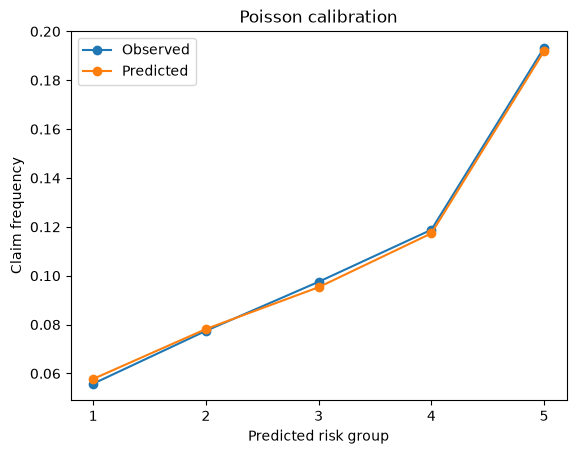

In [23]:
plt.plot(
    cal_table.index,
    cal_table["ObservedFrequency"],
    marker="o",
    label="Observed"
)

plt.plot(
    cal_table.index,
    cal_table["PredictedFrequency"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Predicted risk group")
plt.ylabel("Claim frequency")
plt.title("Poisson calibration")
plt.legend()
plt.show()

## 15. Final model decision

Use the evidence together:

- test Poisson deviance, MAE and RMSE
- predicted vs actual claim frequency
- Poisson dispersion
- AIC for Poisson / Negative Binomial
- calibration
- number of useful predictors retained by LASSO
- interpretability and model complexity

Forward/backward selection and best-subset selection are not used here because the categorical variables create many dummy coefficients and regularization provides a cleaner selection approach. Multi-response regression is not applicable because there is only one response variable.